# Transfer learning with Hoplite-based embedding storage

## Run this tutorial

This tutorial is more than a reference! It's a Jupyter Notebook which you can run and modify on Google Colab or your own computer.

|Link to tutorial|How to run tutorial|
| :- | :- |
| [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kitzeslab/opensoundscape/blob/master/docs/tutorials/train_cnn.ipynb) | The link opens the tutorial in Google Colab. Uncomment the "installation" line in the first cell to install OpenSoundscape. |
| [![Download via DownGit](https://img.shields.io/badge/GitHub-Download-teal?logo=github)](https://minhaskamal.github.io/DownGit/#/home?url=https://github.com/kitzeslab/opensoundscape/blob/master/docs/tutorials/train_cnn.ipynb) | The link downloads the tutorial file to your computer. Follow the [Jupyter installation instructions](https://opensoundscape.org/en/latest/installation/jupyter.html), then open the tutorial file in Jupyter. |

In [1]:
# if this is a Google Colab notebook, install opensoundscape in the runtime environment
if 'google.colab' in str(get_ipython()):
  %pip install "opensoundscape==0.12.1" "jupyter-client<8,>=5.3.4" "ipykernel==6.17.1" "bioacoustics-model-zoo==0.12.0"
  num_workers=0
else:
  # choose cpu parallelization count
  num_workers=4

## Setup

### Import needed packages

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#other utilities and packages
import torch
import pandas as pd
from pathlib import Path
import numpy as np
import pandas as pd
import random 
from glob import glob
import sklearn

from tqdm.autonotebook import tqdm
from sklearn.metrics import average_precision_score, roc_auc_score
from pathlib import Path

#set up plotting
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize']=[15,5] #for large visuals
%config InlineBackend.figure_format = 'retina'

# opensoundscape transfer learning tools
from opensoundscape.ml.shallow_classifier import MLPClassifier

/var/folders/d8/265wdp1n0bn_r85dh3pp95fh0000gq/T/ipykernel_57750/951004154.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Download and prepare training data


#### Download example files
Download a set of aquatic soundscape recordings with annotations of _Rana sierrae_ vocalizations

Option 1: run the cell below

- if you get a 403 error, DataDryad suspects you are a bot. Use Option 2. 

Option 2:

- Download and unzip the `rana_sierrae_2022.zip` folder containing audio and annotations from this [public Dryad dataset](https://datadryad.org/stash/dataset/doi:10.5061/dryad.9s4mw6mn3#readme)
- Move the unzipped `rana_sierrae_2022` folder into the current folder

In [4]:
# # Note: the "!" preceding each line below allows us to run bash commands in a Jupyter notebook
# # If you are not running this code in a notebook, input these commands into your terminal instead
# !wget -O rana_sierrae_2022.zip https://datadryad.org/stash/downloads/file_stream/2722802;
# !unzip rana_sierrae_2022;

#### Prepare audio data
See the train_cnn.ipynb tutorial for step-by-step walkthrough of this process, or just run the cells below to prepare a training set.

In [40]:
# Set this variable to specify where the folder `rana_sierrae_2022` is located:
dataset_path = Path("./rana_sierrae_2022/")

# let's generate clip labels of 5s duration (to match HawkEars) using the raven annotations
# and some utility functions from opensoundscape
from opensoundscape.annotations import BoxedAnnotations

audio_and_raven_files = pd.read_csv(f"{dataset_path}/audio_and_raven_files.csv")
# update the paths to where we have the audio and raven files stored
audio_and_raven_files["audio"] = audio_and_raven_files["audio"].apply(
    lambda x: f"{dataset_path}/{x}"
)
audio_and_raven_files["raven"] = audio_and_raven_files["raven"].apply(
    lambda x: f"{dataset_path}/{x}"
)

annotations = BoxedAnnotations.from_raven_files(
    raven_files=audio_and_raven_files["raven"],
    audio_files=audio_and_raven_files["audio"],
    annotation_column="annotation",
)
# generate labels for 5s clips, including any labels that overlap by at least 0.2 seconds
labels = annotations.clip_labels(
    clip_duration=3, min_label_overlap=0.2, final_clip=None
)

/Users/SML161/opensoundscape/opensoundscape/annotations.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_annotations_df = pd.concat(all_file_dfs).reset_index(drop=True)


#### Inspect labels

Count number of each annotation type: 

Note that the 'X' label is for when the annotator was uncertain about the identity of a call. Labels A-E denote distinct call types.

In [41]:
labels.sum()

A    585
E    154
D     61
B     22
C     91
X    120
dtype: int64

#### split into training and validation data
We'll just focus on class 'A', the call type with the most annotations. We'll randomly split the clips into training and validation data, acknowledging that this approach does not test the ability of the model to generalize. Since the samples in the training and validation sets could be adjascent 2-second audio clips, good performance could simply mean the model has memorized the training samples, and the validation set has very similar samples. 

In [42]:
labels_train, labels_val = sklearn.model_selection.train_test_split(labels[["C"]])

Embed all samples to Hoplite database with a chosen model

In [ ]:
import bioacoustics_model_zoo as bmz

birdnet = bmz.BirdNET()
birdnet.name = "BirdNET v2.4"

downloading model from URL...


In [ ]:
# uncomment and run to remove existing db
# !rm -rf ./agileDB/

In [65]:
from opensoundscape.vector_database import load_or_create_hoplite_usearch_db

db = load_or_create_hoplite_usearch_db(
    "./agileDB/", embedding_dim=birdnet.classifier.in_features
)

Creating new db at agileDB


In [68]:
db, failed_samples = birdnet.embed_to_hoplite_db(
    labels,
    db=db,
    deployment="rana_sierrae_2022",
    num_workers=num_workers,
    batch_size=32,
)

all samples already have embeddings in the database


select one sample of the "chuckle call" - we'll imagine this is the only sample we had to start the process with

display as click-to-play spectrogram

(each time you run the cell it will select a different sample)


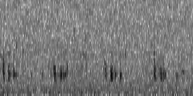

In [75]:
# start with one example of the target sound
from opensoundscape.visualization import inspect, annotate

example_clip = labels[labels["C"] == 1].sample(1)
_ = inspect(example_clip.reset_index(), bandpass_range=(0, 2500))

Find some samples via embedding similarity search and annotate them

annotations will be added to columns of the clips dataframe

In [76]:
# similarity search in the hoplite database
search_results = birdnet.similarity_search_hoplite_db(
    example_clip,
    db,
    num_results=20,
)
search_result_clips = pd.DataFrame(search_results[0]["results"]).reset_index()
_ = annotate(
    search_result_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

embedding query samples


/Users/SML161/opensoundscape/opensoundscape/ml/cnn.py:3047: UserWarning: The columns of input samples df differ from `model.classes`. Discarding sample df columns.
  warnings.warn(


  0%|          | 0/1 [00:00<?, ?it/s]

performing similarity search for each of 1 query samples


GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

Display clip df after annotating:

In [77]:
search_result_clips

,index,window_id,sort_score,start_time,end_time,file,Accept,Reject
0,0,1325,-267.929932,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,True,None
1,1,1628,-238.796814,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,True,None
2,2,671,-234.399353,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,True,None
3,3,1700,-233.012192,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True
4,4,728,-232.808685,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True
5,5,1329,-231.153854,6.0,9.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True
6,6,534,-229.131973,6.0,9.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True
7,7,1593,-226.487045,6.0,9.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True
8,8,401,-226.267365,3.0,6.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,True,None
9,9,1005,-225.524582,6.0,9.0,rana_sierrae_2022/mp3/sine2022a_MSD-0558_20220...,None,True


Hopefully, some of these clips can be used as positive training samples for the class of interest. We can also try starting with a different query sample. 

Now, since we want to train a binary classifier for presence and absence, let's also annotate some randomly selected clips to get a diverse set of negative examples

In [79]:
# annotate random clips
random_clips = labels.sample(20)[[]].reset_index()
_ = annotate(
    random_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

## Train shallow classifier

We'll train our first classifiers on the labels created above

In [80]:
embedding_size = birdnet.classifier.in_features

clf = MLPClassifier(
    input_size=embedding_size,
    output_size=1,
    hidden_layer_sizes=(),
    classes=["RanaSierrae"],
)

Aggregate our labels into a training dataframe with:
- file, start_time, end_time in the index
- 'RanaSierrae' column with 0 for absent and 1 for present

In [ ]:
positive_labels = pd.concat(
    [
        search_result_clips[search_result_clips["Accept"] == True],
        random_clips[random_clips["Accept"] == True],
    ],
    ignore_index=True,
)[["file", "start_time", "end_time"]]
positive_labels["RanaSierrae"] = 1
negative_labels = pd.concat(
    [
        search_result_clips[search_result_clips["Reject"] == True],
        random_clips[random_clips["Reject"] == True],
    ],
    ignore_index=True,
)
negative_labels = negative_labels[["file", "start_time", "end_time"]]
negative_labels["RanaSierrae"] = 0
training_labels = (
    pd.concat([positive_labels, negative_labels], ignore_index=True)
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])
)
training_labels.to_csv("round1_labels.csv")

embed the samples

In [84]:
training_db = load_or_create_hoplite_usearch_db(
    "./rasi_hawkears_train_val/", embedding_dim=birdnet.classifier.in_features
)
emb_db, failed_samples = birdnet.embed_to_hoplite_db(
    training_labels, training_db, deployment="trainval", batch_size=32
)

Creating new db at rasi_hawkears_train_val
embedding 37 new windows to database


  0%|          | 0/2 [00:00<?, ?it/s]

train shallow classifier

In [85]:
from opensoundscape.ml.shallow_classifier import (
    fit_on_hoplite_db,
    predict_on_hoplite,
)
from sklearn.model_selection import train_test_split

train, val = train_test_split(training_labels, test_size=0.5)
fit_on_hoplite_db(
    model=clf,
    hoplite_db=training_db,
    train_df=train,
    validation_df=val,
    steps=300,
    batch_size=128,
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.045, Val Loss: 0.151
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.017, Val Loss: 0.112
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.009, Val Loss: 0.096
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.096 at step 300 of 300
Training complete


{'loss': 0.09648226201534271,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

Let's make some annotations on the most confident predictions

In [ ]:
scores = predict_on_hoplite(db, labels, clf)

# don't review clips we already annotated
scores = scores.drop(index=training_labels.index)
# select top score per audio recorder to review
topk = scores.nlargest(20, "RanaSierrae")
topk = topk.reset_index()
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.


  0%|          | 0/2 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

Let's aggregate the new labels with the old training set, then refine our classifier

In [125]:
topk.Accept.value_counts(), topk.Reject.value_counts()

(Accept
 True    10
 Name: count, dtype: int64,
 Reject
 True    9
 Name: count, dtype: int64)

In [ ]:
# only use clips that were labeled
new_positives = topk[topk["Accept"] == True].copy()
new_positives["RanaSierrae"] = 1
new_negatives = topk[topk["Reject"] == True].copy()
new_negatives["RanaSierrae"] = 0
# aggregate with previous training data
train2 = (
    pd.concat([new_positives, new_negatives, train.reset_index()])
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[["RanaSierrae"]]
)
train2.to_csv("round2_labels.csv")
train2.value_counts("RanaSierrae")

# embed new training data
_ = birdnet.embed_to_hoplite_db(
    train2, training_db, deployment="trainval", batch_size=32
)

all samples already have embeddings in the database


Now, we refine the classifier using the additional labels

In [144]:
fit_on_hoplite_db(
    model=clf,
    hoplite_db=training_db,
    train_df=train2,
    validation_df=val,
    steps=300,
    batch_size=128,
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.032, Val Loss: 0.041
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.013, Val Loss: 0.038
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.007, Val Loss: 0.035
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.035 at step 300 of 300
Training complete


{'loss': 0.03539334982633591,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

Annotation round 2 - let's see if the classifier is honing in on the repeated-note calls

In [152]:
scores = predict_on_hoplite(db, labels, clf)

# don't review clips we already annotated
topk = scores.drop(index=training_labels.index)
# select top score per audio recorder to review
topk = topk.nlargest(20, "RanaSierrae")
topk = topk.reset_index()
_ = annotate(
    topk, bandpass_range=(0, 2500), annotation_buttons=["Accept", "Reject"], N=20
)

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.


  0%|          | 0/2 [00:00<?, ?it/s]

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

The top scores look good. What if we explored the full range of scores?


In [147]:
from opensoundscape.visualization import explore_histogram

_ = explore_histogram(scores, "RanaSierrae", bandpass_range=(0, 2500))

    'data': [{'name': 'all',
              'nbinsx': 30,
              'opacity'…


By looking at samples from various regions of the score histogram, it appears that:
- high scores are correct true positives
- low scores are correct true negatives
- the decision boundary around logit score = 0 has a mix

Therefore, if we aren't satisfied with performance yet, we might want to annotate clips scoring near 0

In [ ]:
# don't review clips we already annotated

uncertain_clips = scores.drop(index=training_labels.index)
# select random clips scoring between -2 and 1 to review
uncertain_clips = uncertain_clips[
    (uncertain_clips["RanaSierrae"] > -2) & (uncertain_clips["RanaSierrae"] < 1)
]
uncertain_clips = uncertain_clips.reset_index()
_ = annotate(
    uncertain_clips,
    bandpass_range=(0, 2500),
    annotation_buttons=["Accept", "Reject"],
    N=20,
)

GridBox(children=(VBox(children=(HTML(value='<img src="data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAJsAAACaC…

refine the classifier one more time

In [ ]:
# incorporate new labels
new_positives = uncertain_clips[uncertain_clips["Accept"] == True].copy()
new_positives["RanaSierrae"] = 1
new_negatives = uncertain_clips[uncertain_clips["Reject"] == True].copy()
new_negatives["RanaSierrae"] = 0
# aggregate with previous training data
train3 = (
    pd.concat([new_positives, new_negatives, train2.reset_index()])
    .drop_duplicates()
    .set_index(["file", "start_time", "end_time"])[["RanaSierrae"]]
)
train3.to_csv("round3_labels.csv")

# embed new training data
_ = birdnet.embed_to_hoplite_db(
    train3, training_db, deployment="trainval", batch_size=32
)
# Now, we refine the classifier using the additional labels
fit_on_hoplite_db(
    model=clf,
    hoplite_db=training_db,
    train_df=train3,
    validation_df=val,
    steps=300,
    batch_size=128,
)

embedding 18 new windows to database


  0%|          | 0/1 [00:00<?, ?it/s]

Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Finding matching window IDs for samples in label_df...
Finished finding matching window IDs.
Epoch 100/300, Loss: 0.042, Val Loss: 0.059
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 200/300, Loss: 0.019, Val Loss: 0.066
	val AU ROC: 1.000
	val MAP: 1.000
Epoch 300/300, Loss: 0.011, Val Loss: 0.067
	val AU ROC: 1.000
	val MAP: 1.000
Loaded best model with validation loss: 0.059 at step 100 of 300
Training complete


{'loss': 0.058870453387498856,
 'auroc': 1.0,
 'map': 1.0,
 'per_class_auroc': [1.0]}

save the classifier to a file:

In [157]:
clf.save("rasi_classifier_round3.pt")

# use later:
# clf = MLPClassifier.load("rasi_classifier_round3.pt")
# field_data_db = birdnet.embed_to_hoplite_db(audio_files, 'field_data_db', deployment='field_data')
# prediction_scores = predict_on_hoplite(field_data_db, audio_files, clf)

Here we can start to see the value of challenging, rich evaluation data - our simple classifiers performed perfectly on our small/weak evaluation set in all rounds, so we can't tell if we're improving!

In [ ]:
# clean up by deleting files and folders generated in this tutorial (uncomment to run)
# import shutil

# shutil.rmtree("./agileDB/")
# shutil.rmtree("./rasi_hawkears_train_val/")
# import os

# os.remove("round1_labels.csv")
# os.remove("round2_labels.csv")
# os.remove("round3_labels.csv")
# os.remove("rasi_classifier_round3.pt")